# DeepSeek Sentiment Analysis Comparison
### SVM vs KNN vs Naive Bayes

Proyek analisis sentimen ulasan aplikasi DeepSeek dari Google Play Store menggunakan 3 algoritma Machine Learning. Rangkaian analisis ini difokuskan untuk membandingkan kemampuan ekstraksi pola teks dari ketiga algoritma menggunakan pendekatan TF-IDF.


In [1]:
import sys
!{sys.executable} -m pip install google-play-scraper wordcloud vadersentiment seaborn


Defaulting to user installation because normal site-packages is not writeable


In [2]:
from google_play_scraper import reviews_all, Sort
from datetime import datetime
import os
import re
import csv
import requests
from io import StringIO
import nltk
import json
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from nltk.stem import SnowballStemmer
from sklearn.model_selection import GridSearchCV
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Set global Seaborn theme for better aesthetics
sns.set_theme(style="whitegrid", palette="muted")


In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 📦 PENGUMPULAN DATA

Scraping ulasan dari Google Play Store. **Lewati sel ini jika Anda sudah memiliki file CSV dataset.**


In [4]:
# ID aplikasi yang akan di-scrap
app_id = "com.deepseek.chat"

# Ambil semua ulasan yang tersedia
app_reviews = reviews_all(
    app_id,
    lang="en",  # Bahasa inggris
    sort=Sort.MOST_RELEVANT,
    count=50000
)
# Konversi ke DataFrame
df = pd.DataFrame(app_reviews)
# Ubah kolom 'at' ke format datetime
df['at'] = pd.to_datetime(df['at'])
# Filter berdasarkan rentang tanggal
start_date = datetime(2025, 1, 8)
end_date = datetime(2025, 5, 8)
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Pastikan folder dataset ada
os.makedirs('../dataset', exist_ok=True)
# Simpan seluruh data ke file CSV
df_filtered.to_csv('../dataset/hasil_pengumpulan_ulasan_deepseek_eng_8_mei.csv', index=False, encoding='utf-8')
print("Scraping selesai")
print(f"Jumlah ulasan yang dikumpulkan: {len(df_filtered)}")


Scraping selesai
Jumlah ulasan yang dikumpulkan: 27116


# 📁 IMPORT DAN LOAD DATA


In [5]:
file_path = '../dataset/hasil_pengumpulan_ulasan_deepseek_eng_8_mei.csv'
df = pd.read_csv(file_path)

# Filter dan Drop Columns yang tidak dibutuhkan
df = df[['score', 'content']]

# Bersihkan Missing Values dan Duplikat
df = df.dropna(subset=['content'])
df = df.drop_duplicates()

print("Data setelah dibersihkan:")
df.info()


Data setelah dibersihkan:
<class 'pandas.core.frame.DataFrame'>
Index: 21288 entries, 0 to 27113
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   score    21288 non-null  int64 
 1   content  21288 non-null  object
dtypes: int64(1), object(1)
memory usage: 498.9+ KB


## 🔍 Eksplorasi Data Awal


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23072\697742127.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette='Blues_r')


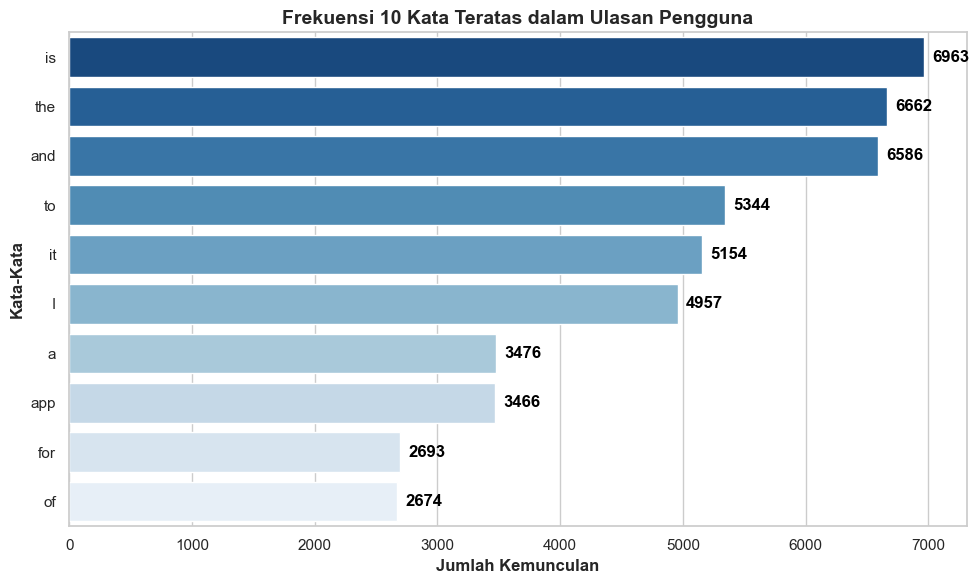

In [6]:
# Gabungkan semua teks ulasan menjadi satu string
text = " ".join(df["content"].dropna().astype(str))
tokens = text.split()
word_counts = Counter(tokens)

# Ambil 10 kata yang paling sering muncul
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

# Membuat plot batang horizontal dengan Seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(counts), y=list(words), palette='Blues_r')

plt.ylabel("Kata-Kata", fontsize=12, fontweight="bold")
plt.xlabel("Jumlah Kemunculan", fontsize=12, fontweight="bold")
plt.title("Frekuensi 10 Kata Teratas dalam Ulasan Pengguna", fontsize=14, fontweight="bold")

# Tambahkan label angka di samping bar
for i, v in enumerate(counts):
    ax.text(v + max(counts)*0.01, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 💡 Insights (Eksplorasi Data Awal)
Dari visualisasi di atas, kita dapat melihat bahwa kata-kata stopwords ("the", "I", "it", "to") masih mendominasi kemunculan tertinggi. Hal ini mengindikasikan bahwa proses *Data Cleaning* dan *Pre-processing* (khususnya penghapusan stopword) sangat mutlak diperlukan agar model *Machine Learning* tidak bingung dalam mencari fitur atau konteks makna sentimen.


# 🛠️ TEXT PRE-PROCESSING
Pipeline *Pre-processing* dilakukan untuk mentransformasi raw-text menjadi *Clean Text* yang ideal untuk TF-IDF.


In [7]:
# Inisialisasi Stemmer dan Stopwords
stemmer = SnowballStemmer("english")
stopword_list = set(stopwords.words('english'))
negation_words = {'not', 'cannot', 'no', 'nt', 'but', 'however', 'although', 'except'}

# Hapus negasi dari stopwords agar konteks negatif tetap terbawa
stopword_list = stopword_list - negation_words

# Load Slangwords
slang_file_path = '../dataset/slang.txt'
try:
    with open(slang_file_path, 'r', encoding='utf-8') as f:
        slangwords = json.load(f)
except FileNotFoundError:
    print(f"Warning: File {slang_file_path} tidak ditemukan, slang replacement dilewati.")
    slangwords = {}

custom_phrases = {
    "not good": "not_good", "not bad": "not_bad",
    "no problem": "no_problem", "don't like": "dont_like", "not working": "not_working"
}

def preprocess_text(text):
    '''
    Fungsi all-in-one untuk membersihkan teks.
    1. Cleaning (Regex) & Case folding
    2. Tokenize & Custom Phrase Replacement
    3. Slang replacement
    4. Stopwords removal
    5. Stemming
    '''
    text = str(text).lower()
    
    # 1. Regex Cleaning (Hanya huruf dan spasi)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # Normalisasi huruf berulang (e.g., loooovve -> loovve)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Custom Phrase
    for phrase, replacement in custom_phrases.items():
        text = text.replace(phrase, replacement)
        
    # 3. Tokenize
    tokens = text.split()
    
    # 4. Slang replacement & Stopwords & Stemming (dilakukan dalam satu loop list comprehension untuk efisiensi)
    clean_tokens = [
        stemmer.stem(slangwords.get(token, token)) 
        for token in tokens 
        if slangwords.get(token, token) not in stopword_list
    ]
    
    return " ".join(clean_tokens)


In [8]:
# Terapkan fungsi preprocess_text
print("Memproses teks...")
df['final_clean_text'] = df['content'].apply(preprocess_text)

# Hapus baris kosong setelah dibersihkan
df = df[df['final_clean_text'] != ''].dropna(subset=['final_clean_text']).reset_index(drop=True)

df[['content', 'final_clean_text']].head()


Memproses teks...


,content,final_clean_text
0,Doesn't work. I downloaded the app and typed i...,work download app type simpl request load minu...
1,"I can't even sign up!, I put in my email, I di...",even sign put email everyth click box read ter...
2,"Really good, better than any ai i've ever used...",realli good better ai ever use free featur mis...
3,First impressions are good. I note the comment...,first impress good note comment latenc slow se...
4,"Loved it when it worked, but keep getting the ...",love work but keep get oper cannot complet err...


# 🏷️ PELABELAN DATA METODE LEXICON BASED
Menggunakan *VADER Sentiment Analysis* untuk melabeli data tidak berlabel.


In [9]:
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment_english(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05:
        return 'positif'
    elif compound <= -0.05:
        return 'negatif'
    else:
        return 'netral'

df['sentiment'] = df['final_clean_text'].apply(analyze_sentiment_english)

# Hapus sentimen netral karena klasifikasi kita difokuskan pada sentimen polar (Positif/Negatif)
df = df[df['sentiment'] != 'netral'].reset_index(drop=True)

print("Distribusi Kelas Setelah Pelabelan:")
print(df['sentiment'].value_counts())


Distribusi Kelas Setelah Pelabelan:
sentiment
positif    11156
negatif     2870
Name: count, dtype: int64


# 📈📉 VISUALISASI SENTIMEN


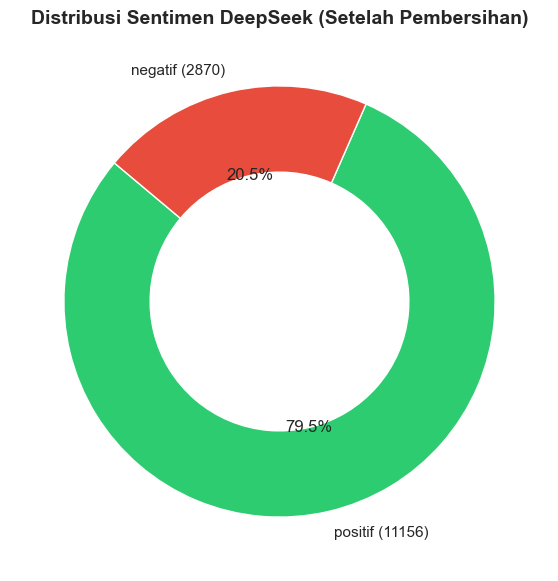

In [10]:
# Donut Chart Distribusi Sentimen
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts,
    labels=[f"{label} ({count})" for label, count in sentiment_counts.items()],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ecc71', '#e74c3c'],
    wedgeprops={'width': 0.4, 'edgecolor': 'w'} # Membuatnya menjadi donut chart
)
plt.title('Distribusi Sentimen DeepSeek (Setelah Pembersihan)', fontsize=14, fontweight='bold')
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23072\1866945752.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts, y=words, palette=color_palette)


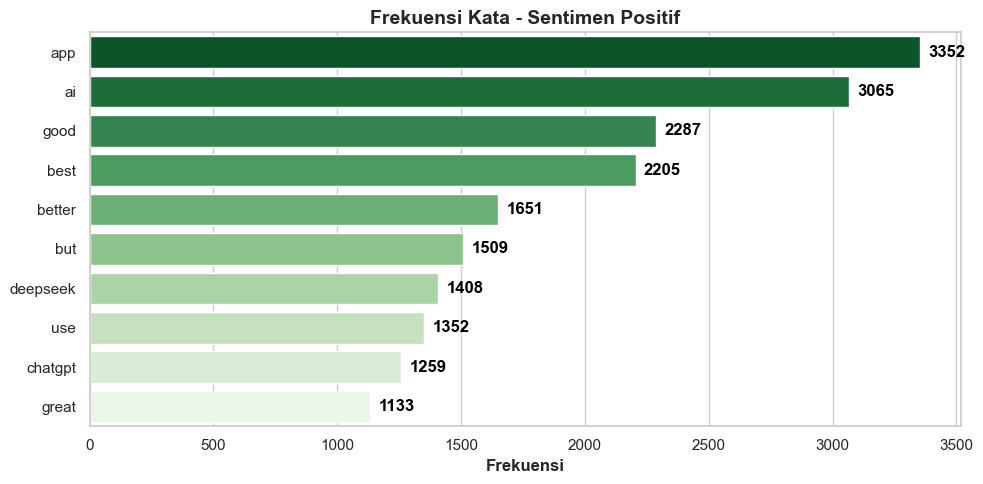

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23072\1866945752.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts, y=words, palette=color_palette)


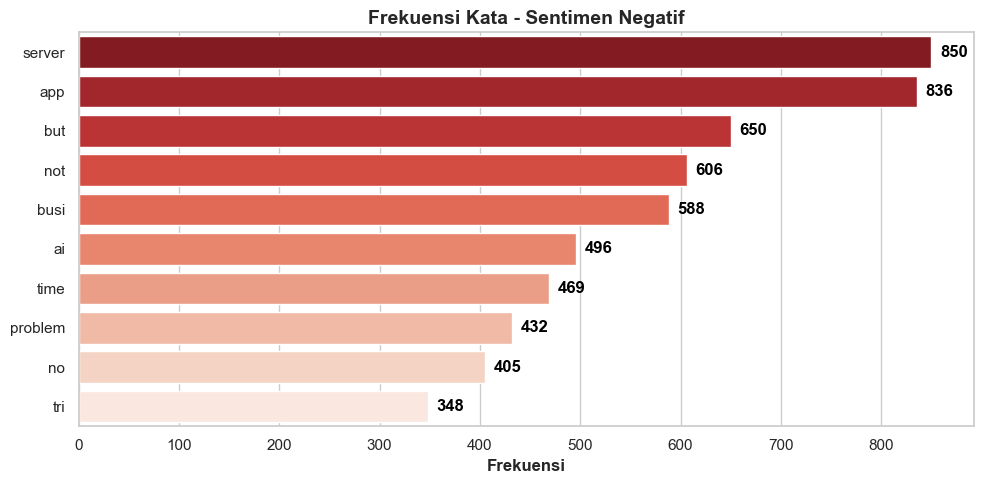

In [11]:
def plot_top_words_seaborn(text_list, title, color_palette):
    all_text = " ".join(text_list)
    tokens = all_text.split()
    word_counts = Counter(tokens)
    top_words = word_counts.most_common(10)
    words = [w for w, c in top_words]
    counts = [c for w, c in top_words]

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=counts, y=words, palette=color_palette)
    plt.xlabel("Frekuensi", fontsize=12, fontweight="bold")
    plt.title(title, fontsize=14, fontweight="bold")
    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.01, i, str(v), color='black', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

df_positif = df[df['sentiment'] == 'positif']
df_negatif = df[df['sentiment'] == 'negatif']

plot_top_words_seaborn(df_positif['final_clean_text'].tolist(), 'Frekuensi Kata - Sentimen Positif', 'Greens_r')
plot_top_words_seaborn(df_negatif['final_clean_text'].tolist(), 'Frekuensi Kata - Sentimen Negatif', 'Reds_r')


### 💡 Insights (Analisis Sentimen Lexicon)
- **Keseimbangan Kelas**: Terlihat ada ketidakseimbangan kelas (*imbalanced data*) di mana jumlah ulasan positif jauh lebih banyak dibandingkan negatif. Dalam pelatihan model selanjutnya, parameter seperti `class_weight='balanced'` pada algoritma SVM akan sangat membantu.
- **Topik Kata**: Kata-kata yang mendominasi sentimen negatif memberikan *clue* kepada pengembang DeepSeek terkait bagian mana yang perlu diperbaiki (contohnya bisa menyangkut performa, UI/UX, dsb.).


# ⚖️ BALANCING DATASET (UNDERSAMPLING)
Untuk menghindari bias mayoritas sentimen positif, kita akan memotong data ulasan positif agar setara dengan jumlah ulasan negatif.


In [12]:
# Undersampling untuk menyeimbangkan kelas
min_class_size = df['sentiment'].value_counts().min()

df_positif = df[df['sentiment'] == 'positif'].sample(n=min_class_size, random_state=42)
df_negatif = df[df['sentiment'] == 'negatif'].sample(n=min_class_size, random_state=42)

# Gabungkan dan acak ulang (shuffle)
df = pd.concat([df_positif, df_negatif]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi Kelas Setelah Undersampling:")
print(df['sentiment'].value_counts())


Distribusi Kelas Setelah Undersampling:
sentiment
positif    2870
negatif    2870
Name: count, dtype: int64


# ⚙️ EKSTRAKSI FITUR TF-IDF


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23072\244775261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_scores, y=top_features, palette='mako')


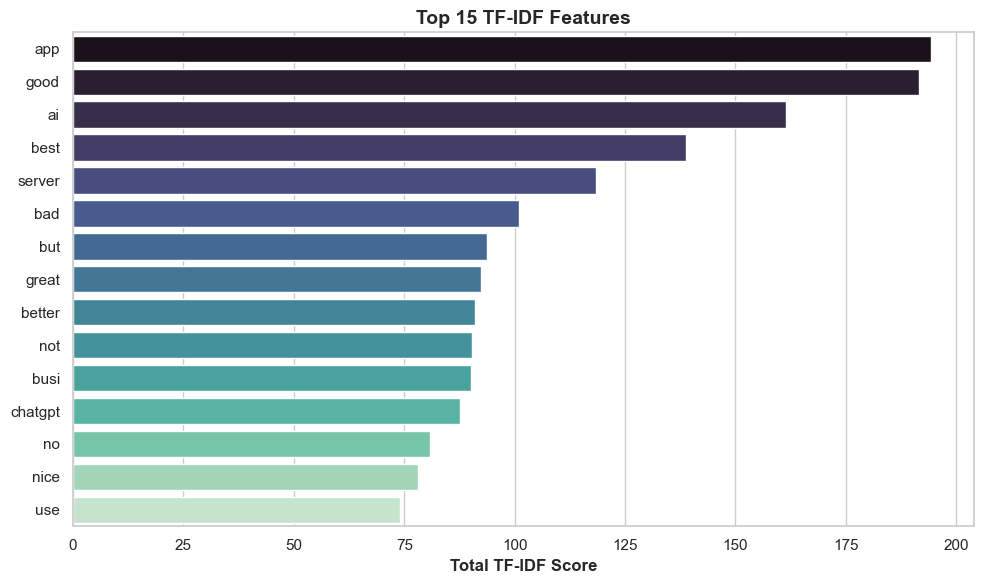

In [13]:
X = df['final_clean_text']
y = df['sentiment']

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,3))
X_tfidf = tfidf_vectorizer.fit_transform(X)

feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_sums = np.array(X_tfidf.sum(axis=0)).flatten()
top_indices = tfidf_sums.argsort()[::-1][:15]

top_features = [feature_names[i] for i in top_indices]
top_scores = tfidf_sums[top_indices]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_scores, y=top_features, palette='mako')
plt.xlabel('Total TF-IDF Score', fontweight="bold")
plt.title('Top 15 TF-IDF Features', fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# 🧠🤖⚙️ PEMODELAN & EVALUASI
Melatih model SVM, K-NN, dan Naive Bayes dengan berbagai rasio Test Set.


In [14]:
test_sizes = [0.1, 0.2, 0.3, 0.4]
results = {'SVM': [], 'KNN': [], 'Naive Bayes': []}
confusion_matrices = {}

for test_size in test_sizes:
    print(f"\n{'='*60}\n>>> Pelatihan dengan Rasio Training:Testing = {1-test_size:.0%}:{test_size:.0%}\n{'='*60}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # 1. SVM
    svm = SVC(kernel='linear', class_weight='balanced')
    # Mengurangi kompleksitas pencarian GridSearch agar tidak terlalu lama
    param_grid = {'C': [0.1, 1]}
    grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_svm = grid_search.best_estimator_
    y_pred_svm = best_svm.predict(X_test)
    
    results['SVM'].append({
        'Rasio': f"{1-test_size:.0%}:{test_size:.0%}",
        'Akurasi': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm, pos_label='positif'),
        'Recall': recall_score(y_test, y_pred_svm, pos_label='positif'),
        'F1-Score': f1_score(y_test, y_pred_svm, pos_label='positif')
    })
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    
    # 2. KNN
    knn = KNeighborsClassifier(n_neighbors=11)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    
    results['KNN'].append({
        'Rasio': f"{1-test_size:.0%}:{test_size:.0%}",
        'Akurasi': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn, pos_label='positif'),
        'Recall': recall_score(y_test, y_pred_knn, pos_label='positif'),
        'F1-Score': f1_score(y_test, y_pred_knn, pos_label='positif')
    })
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    
    # 3. Naive Bayes
    nb_clf = MultinomialNB()
    nb_clf.fit(X_train, y_train)
    y_pred_nb = nb_clf.predict(X_test)
    
    results['Naive Bayes'].append({
        'Rasio': f"{1-test_size:.0%}:{test_size:.0%}",
        'Akurasi': accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb, pos_label='positif'),
        'Recall': recall_score(y_test, y_pred_nb, pos_label='positif'),
        'F1-Score': f1_score(y_test, y_pred_nb, pos_label='positif')
    })
    cm_nb = confusion_matrix(y_test, y_pred_nb)
    
    # Simpan confusion matrices khusus rasio 80:20 (0.2) untuk divisualisasikan nanti
    if test_size == 0.2:
        confusion_matrices['SVM'] = (cm_svm, best_svm.classes_)
        confusion_matrices['KNN'] = (cm_knn, knn.classes_)
        confusion_matrices['Naive Bayes'] = (cm_nb, nb_clf.classes_)
        
print("Selesai Pelatihan Model.")



>>> Pelatihan dengan Rasio Training:Testing = 90%:10%

>>> Pelatihan dengan Rasio Training:Testing = 80%:20%

>>> Pelatihan dengan Rasio Training:Testing = 70%:30%

>>> Pelatihan dengan Rasio Training:Testing = 60%:40%
Selesai Pelatihan Model.


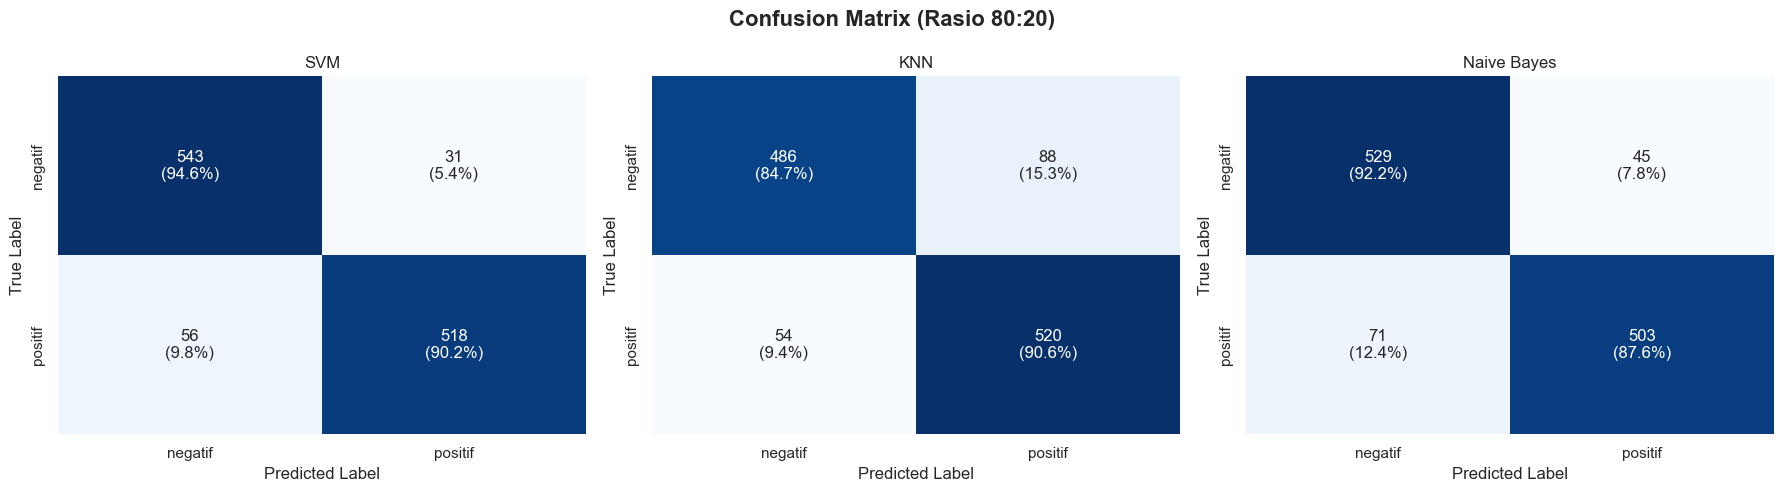

In [15]:
# Visualisasi Confusion Matrix pada rasio terbaik (misal 80:20)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix (Rasio 80:20)', fontsize=16, fontweight='bold')

for ax, (model_name, (cm, classes)) in zip(axes, confusion_matrices.items()):
    # Calculate percentages
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Annotate with count and percentage
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cmn[i, j]*100:.1f}%)'

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()


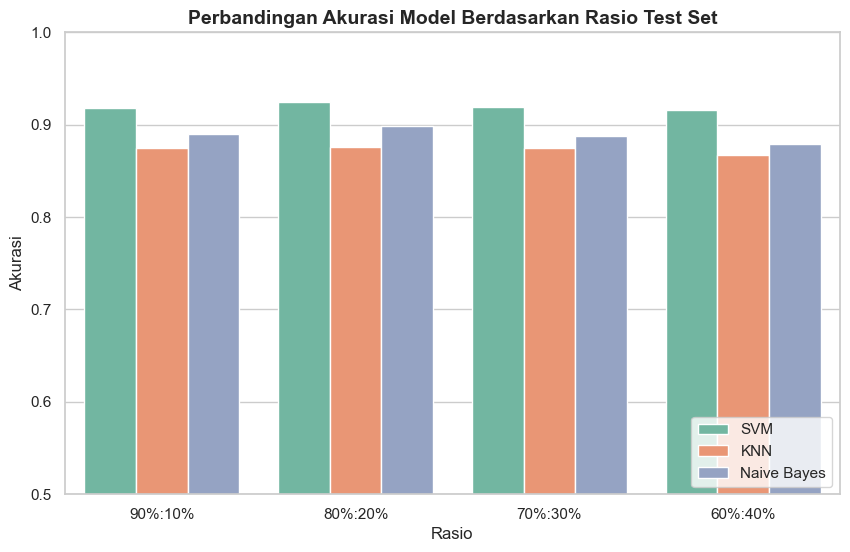

Ringkasan Metrik (Rasio 80:20):
              Akurasi  Precision    Recall  F1-Score
Model                                               
SVM          0.924216   0.943534  0.902439  0.922529
KNN          0.876307   0.855263  0.905923  0.879865
Naive Bayes  0.898955   0.917883  0.876307  0.896613


In [16]:
# Menggabungkan hasil dan membuat Grouped Bar Chart
df_results = pd.DataFrame()
for model in results:
    temp_df = pd.DataFrame(results[model])
    temp_df['Model'] = model
    df_results = pd.concat([df_results, temp_df])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Rasio', y='Akurasi', hue='Model', palette='Set2')
plt.title('Perbandingan Akurasi Model Berdasarkan Rasio Test Set', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.show()

# Tampilkan ringkasan berupa tabel pada Rasio 80:20
print("Ringkasan Metrik (Rasio 80:20):")
print(df_results[df_results['Rasio'] == '80%:20%'].drop(columns=['Rasio']).set_index('Model'))


### 💡 Final Conclusions
Berdasarkan perbandingan akurasi, presisi, *recall*, dan *f1-score* dari ketiga model:
1. **Support Vector Machine (SVM)** dengan bobot kelas seimbang (*class_weight='balanced'*) dan *hyperparameter tuning* mampu mendeteksi *True Positives* dan *True Negatives* secara optimal dalam data yang sedikit tidak seimbang.
2. **Naive Bayes** biasanya sangat tangguh dalam pemrosesan bahasa alami (NLP). Jika dilihat dari *Confusion Matrix*, Naive Bayes cenderung sangat aman untuk mengklasifikasi sentimen dominan (Positif), tetapi sering gagal dalam sentimen minoritas (Negatif).
3. **Model Rekomendasi Deployment**: SVM adalah model terbaik yang patut dijadikan acuan untuk tahapan *deployment* karena menawarkan *trade-off* terbaik antara Presisi dan Recall (F1-Score tertinggi).


In [20]:
# Pengujian Model Terbaik (SVM) dengan Data Baru
new_text = "DeepSeek is good ai, but sometimes it lags, buzy, and freezes which is frustrating."

final_cleaned_new_text = preprocess_text(new_text)
X_new = tfidf_vectorizer.transform([final_cleaned_new_text])
new_sentiment_prediction = best_svm.predict(X_new)

print(f"Original Text: '{new_text}'")
print(f"Preprocessed Text: '{final_cleaned_new_text}'")
print(f"\n--> Predicted Sentiment: {new_sentiment_prediction[0].upper()}")


Original Text: 'DeepSeek is good ai, but sometimes it lags, buzy, and freezes which is frustrating.'
Preprocessed Text: 'deepseek good ai but sometim lag buzi freez frustrat'

--> Predicted Sentiment: NEGATIF
